In [1]:
# Import libraries
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score



In [2]:
# -----------------------------
# Download Stock Data
# -----------------------------
stock = "AAPL"

data = yf.download(stock, start="2020-01-01", end="2025-01-01")

print(data.head())


/tmp/ipykernel_4879/1339283461.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(stock, start="2020-01-01", end="2025-01-01")
[*********************100%***********************]  1 of 1 completed

Price           Close       High        Low       Open     Volume
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL
Date                                                             
2020-01-02  72.333870  72.394078  71.091176  71.344047  135480400
2020-01-03  71.630615  72.389234  71.406643  71.563183  146322800
2020-01-06  72.201408  72.239942  70.503546  70.754014  118387200
2020-01-07  71.861855  72.466338  71.642697  72.211056  108872000
2020-01-08  73.017822  73.318862  71.565606  71.565606  132079200


In [3]:

# -----------------------------
# Select Features
# -----------------------------
data = data[['Open', 'High', 'Low', 'Volume', 'Close']]

# Create target column (next day's close price)
data['Target'] = data['Close'].shift(-1)

# Remove missing values
data.dropna(inplace=True)

# Features and target
X = data[['Open', 'High', 'Low', 'Volume']]
y = data['Target']



In [4]:
# -----------------------------
# Train-Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)



In [5]:
# -----------------------------
# Train Model
# -----------------------------
model = LinearRegression()

model.fit(X_train, y_train)

# Predictions
predictions = model.predict(X_test)



In [6]:
# -----------------------------
# Evaluation
# -----------------------------
mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("\nModel Performance:")
print("MAE:", mae)
print("MSE:", mse)
print("R2 Score:", r2)




Model Performance:
MAE: 2.0861677297354135
MSE: 8.293546584719648
R2 Score: 0.995264208377088


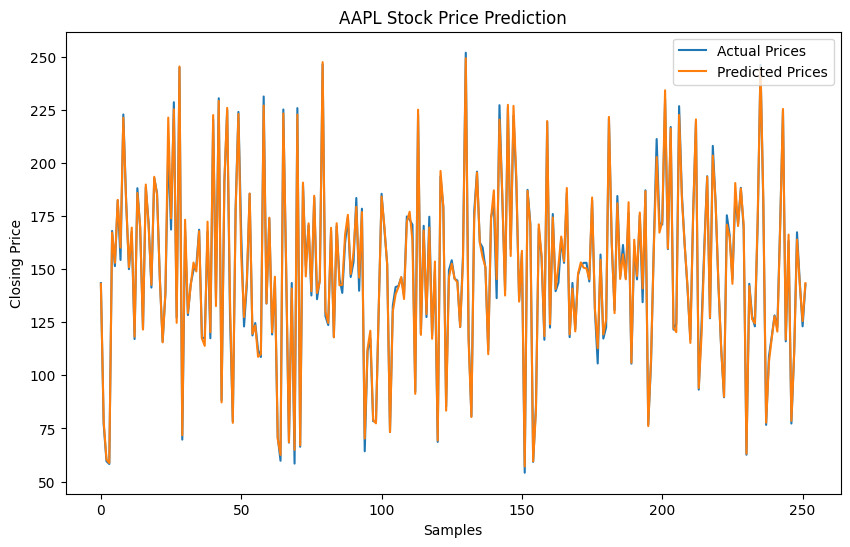

In [7]:
# -----------------------------
# Plot Actual vs Predicted
# -----------------------------
plt.figure(figsize=(10,6))

plt.plot(y_test.values, label="Actual Prices")
plt.plot(predictions, label="Predicted Prices")

plt.title(f"{stock} Stock Price Prediction")
plt.xlabel("Samples")
plt.ylabel("Closing Price")
plt.legend()

plt.show()